<a href="https://colab.research.google.com/github/ArifahZhafirah/PCVK26_04_Arifah/blob/main/P6_Week6_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Sell Identitas

In [115]:
NAMA = 'Arifah Zhafirah Wikananda'

NIM = '244107020188'

print(NAMA, NIM)

Arifah Zhafirah Wikananda 244107020188


1. Buat fungsi konvolusi menggunakan algoritma yang telah dijelaskan pada Bagian C, tanpa menggunakan library atau metode konvolusi dari OpenCV.  

2. Berikut merupakan langkah-langkah yang dapat dilakukan:

A. Buat notebook baru pada google colab, dan beri nama Week6_<No Absen>.ipynb. Simpan Salinan pada akun github seperti pada modul sebelumnya.

B.Mengakses file yang terdapat pada drive dan mengimport beberapa library yang dibutuhkan

In [116]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [117]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

C.Membuat Fungsi Konvolusi

In [118]:
def convolution2d(image, kernel, stride=1, padding=0):
    image = image.astype(np.float64)
    kH, kW = kernel.shape

    # tambahkan padding nol di sekeliling citra
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)),
                       mode='constant', constant_values=0)

    H, W = image.shape
    out_h = (H - kH) // stride + 1
    out_w = (W - kW) // stride + 1
    output = np.zeros((out_h, out_w))

    # geser kernel ke seluruh citra
    for i in range(out_h):
        for j in range(out_w):
            region = image[i*stride : i*stride + kH,
                           j*stride : j*stride + kW]
            output[i, j] = np.sum(region * kernel)

    return output

In [119]:
f = np.array([[4,4,3,5,4],
              [6,6,5,5,2],
              [5,6,6,6,2],
              [6,7,5,5,3],
              [3,5,2,4,4]])
k = np.array([[0,-1,0],
              [-1,4,-1],
              [0,-1,0]])

print(convolution2d(f, k))

[[3. 0. 2.]
 [0. 2. 6.]
 [6. 0. 2.]]


D.Load citra akan diproses dan diubah menjadi citra keabuan

(512, 512)


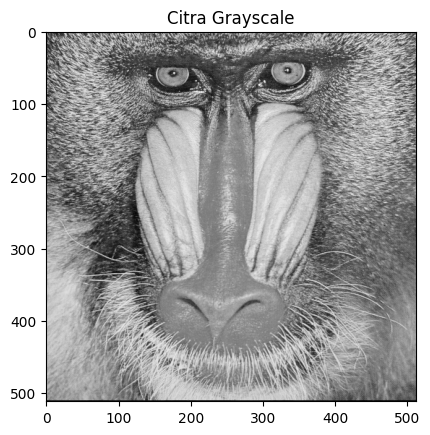

In [120]:
img = cv.imread('/content/drive/MyDrive/Semester5/PCVK/P6_Arifah_04/mandrill.tiff')
assert img is not None, "Gambar tidak ditemukan, cek lagi path-nya"
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

print(img_gray.shape)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Grayscale')
plt.show()

E.Menentukan Kernel yang akan digunakan

In [121]:
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

kernel_emboss = np.array([[-2, -1, 0],
                          [-1,  1, 1],
                          [ 0,  1, 2]])

kernel_sobel_left = np.array([[1, 0, -1],
                              [2, 0, -2],
                              [1, 0, -1]])

kernel_canny = np.array([[-1, -1, -1],
                         [-1,  8, -1],
                         [-1, -1, -1]])

kernel_average = np.ones((3, 3)) / 9

kernel_lowpass = np.array([[1, 1, 1],
                           [1, 4, 1],
                           [1, 1, 1]]) / 12

kernel_highpass = np.array([[-1, 0, 1],
                            [-1, 0, 3],
                            [-3, 0, 1]])

def gaussian_2d(kernel_size):
    sigma = math.sqrt(kernel_size)
    g = cv.getGaussianKernel(kernel_size, sigma)
    return g @ g.T

kernel_gauss21 = gaussian_2d(21)

F.Memanggil fungsi konvolusi yang telah dibuat sebelumnya

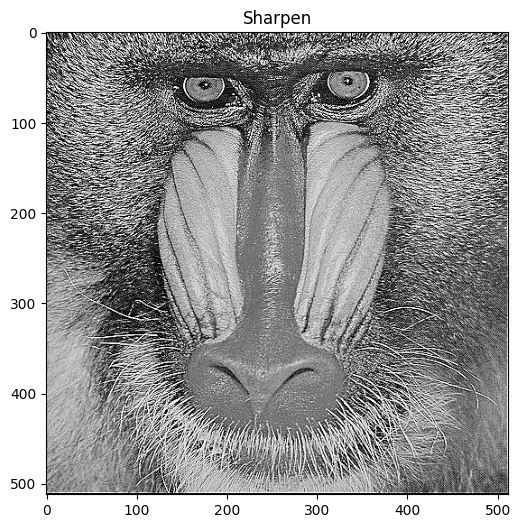

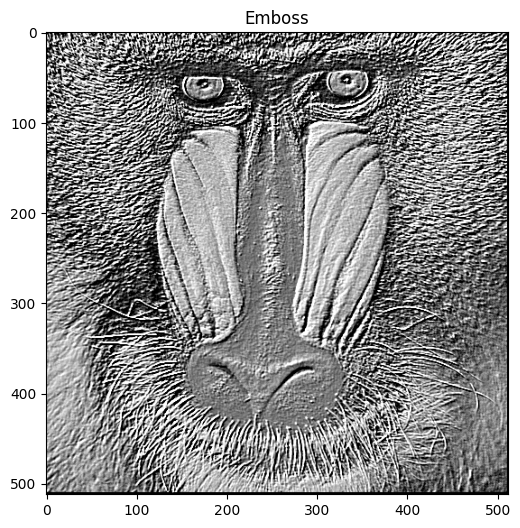

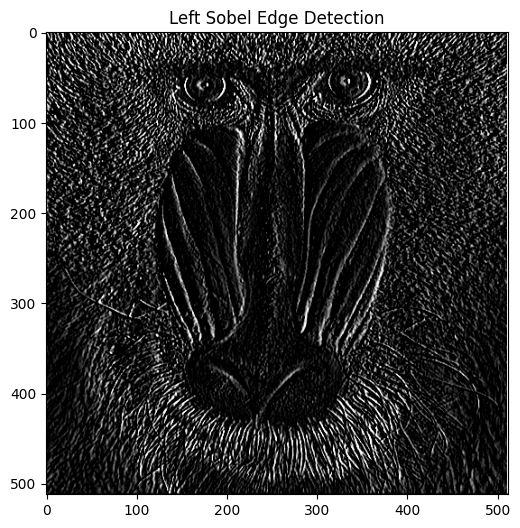

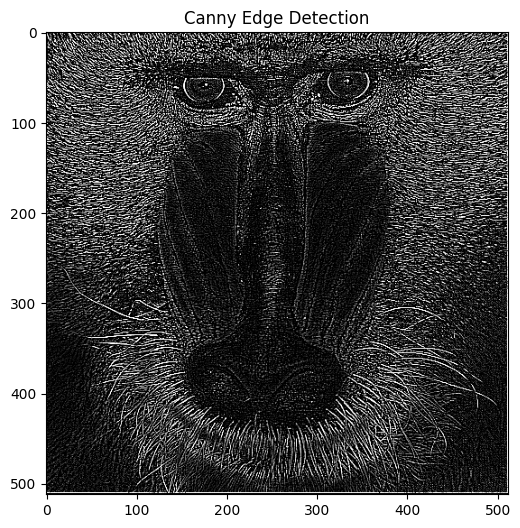

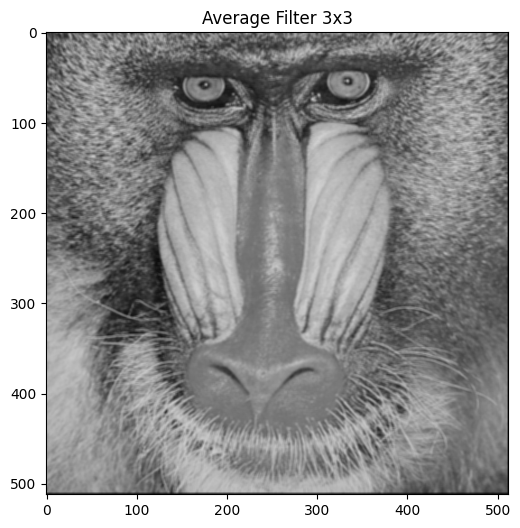

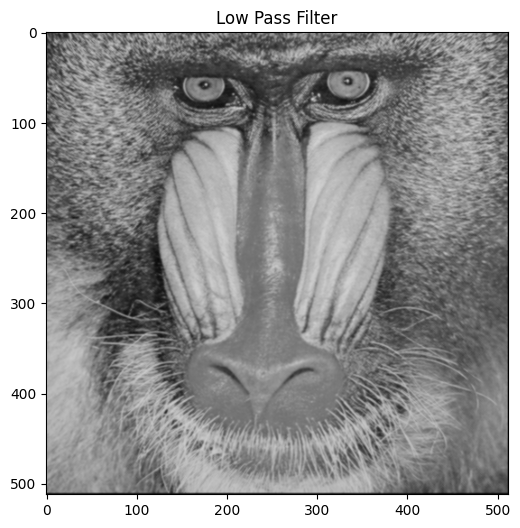

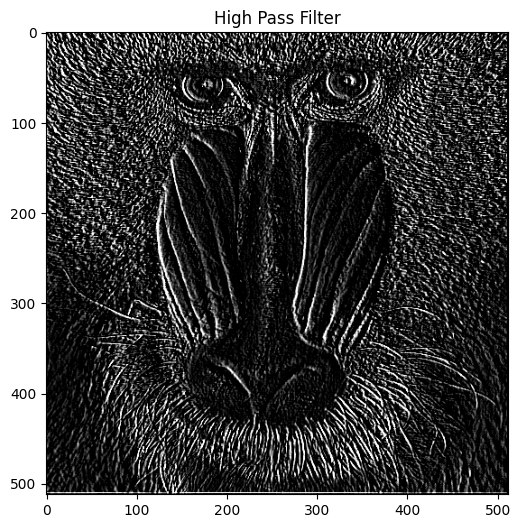

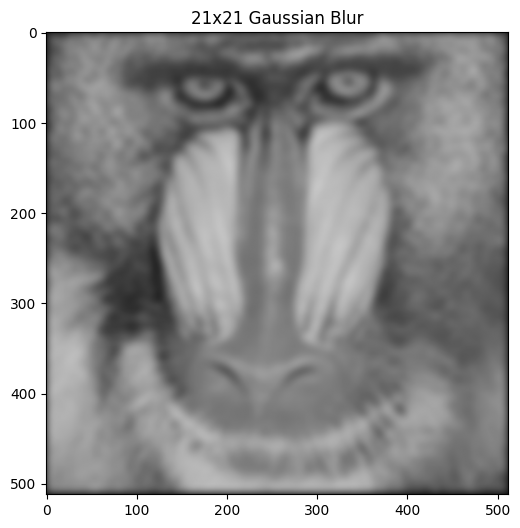

In [122]:
def tampilkan(hasil, judul):
    hasil = np.clip(hasil, 0, 255).astype(np.uint8)
    plt.figure(figsize=(6, 6))
    plt.imshow(hasil, cmap='gray', vmin=0, vmax=255)
    plt.title(judul)
    plt.show()

filters = {
    'Sharpen': (kernel_sharpen, 1),
    'Emboss': (kernel_emboss, 1),
    'Left Sobel Edge Detection': (kernel_sobel_left, 1),
    'Canny Edge Detection': (kernel_canny, 1),
    'Average Filter 3x3': (kernel_average, 1),
    'Low Pass Filter': (kernel_lowpass, 1),
    'High Pass Filter': (kernel_highpass, 1),
    '21x21 Gaussian Blur': (kernel_gauss21, 10),
}

hasil_filter = {}
for nama, (kernel, pad) in filters.items():
    hasil_filter[nama] = convolution2d(img_gray, kernel, stride=1, padding=pad)
    tampilkan(hasil_filter[nama], nama)

3. Membuat Image Filter untuk Average filter, low pass filter, high pass filter, dan beberapa filter lainnya:

In [123]:
kernel_average  = np.ones((3, 3)) / 9

kernel_lowpass  = np.array([[1, 1, 1],
                            [1, 4, 1],
                            [1, 1, 1]]) / 12

kernel_highpass = np.array([[-1, 0, 1],
                            [-1, 0, 3],
                            [-3, 0, 1]])

kernel_sharpen  = np.array([[ 0, -1,  0],
                            [-1,  5, -1],
                            [ 0, -1,  0]])

kernel_emboss   = np.array([[-2, -1, 0],
                            [-1,  1, 1],
                            [ 0,  1, 2]])

kernel_sobel    = np.array([[1, 0, -1],
                            [2, 0, -2],
                            [1, 0, -1]])

kernel_canny    = np.array([[-1, -1, -1],
                            [-1,  8, -1],
                            [-1, -1, -1]])

kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

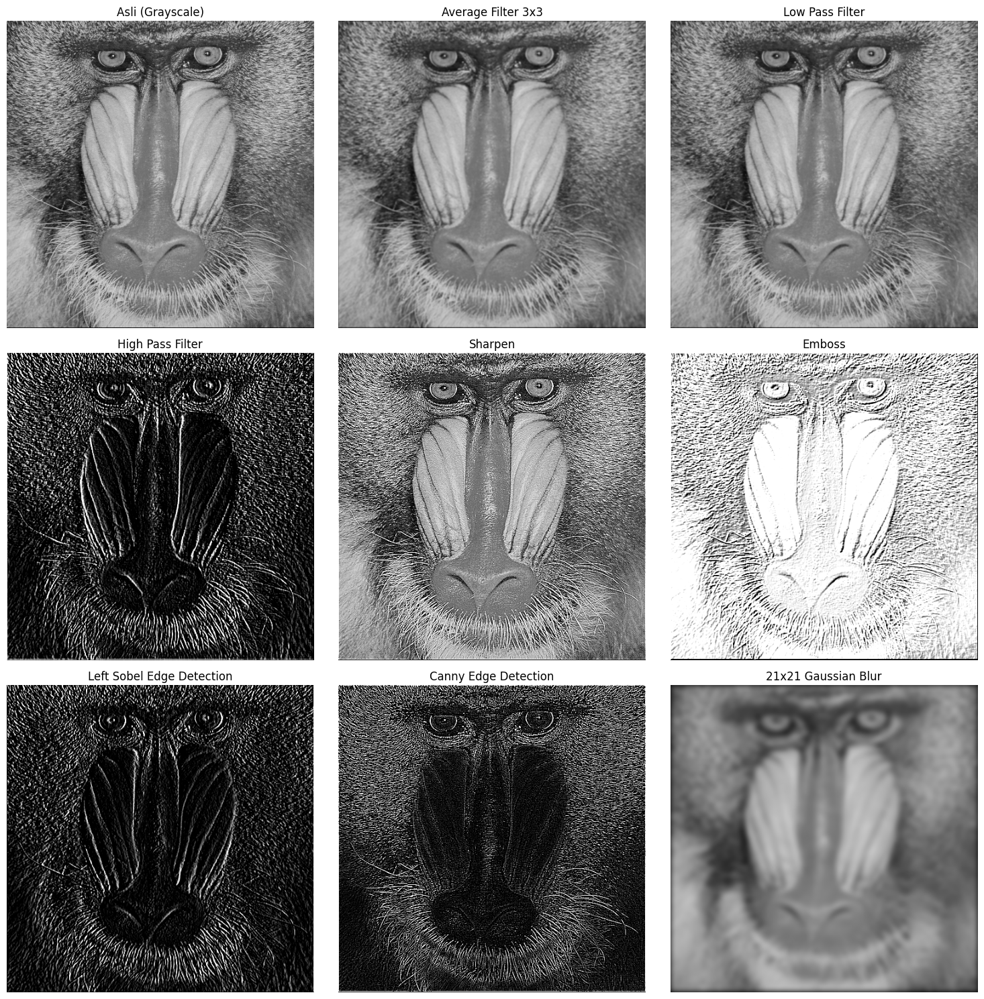

In [124]:
def norm(hasil, offset=0):
    return np.clip(hasil + offset, 0, 255).astype(np.uint8)

# (judul, kernel, padding, offset)
daftar_filter = [
    ('Average Filter 3x3',        kernel_average,  1,  0),
    ('Low Pass Filter',           kernel_lowpass,  1,  0),
    ('High Pass Filter',          kernel_highpass, 1,  0),
    ('Sharpen',                   kernel_sharpen,  1,  0),
    ('Emboss',                    kernel_emboss,   1,  128),
    ('Left Sobel Edge Detection', kernel_sobel,    1,  0),
    ('Canny Edge Detection',      kernel_canny,    1,  0),
    ('21x21 Gaussian Blur',       gauss_kernel,    10, 0),
]

judul = ['Asli (Grayscale)']
hasil = [img_gray]
for nama, k, pad, off in daftar_filter:
    out = convolution2d(img_gray, k, stride=1, padding=pad)
    hasil.append(norm(out, off))
    judul.append(nama)

plt.figure(figsize=(15, 15))
for i, (h, j) in enumerate(zip(hasil, judul)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(h, cmap='gray', vmin=0, vmax=255)
    plt.title(j)
    plt.axis('off')
plt.tight_layout()
plt.show()

#E. Filter Library dan Filter Modern

Percobaan 1: Pada percobaan 1 ini, kita akan membuat Filter Gaussian, Sharpen, dan Canny menggunakan library filter2d dari OpenCV. Filter ini akan kita terapkan pada Image RGB. Pada bagian awal kode terdapat fungsi show_side_by_side yang digunakan untuk menampilkan gambar secara berdampingan.

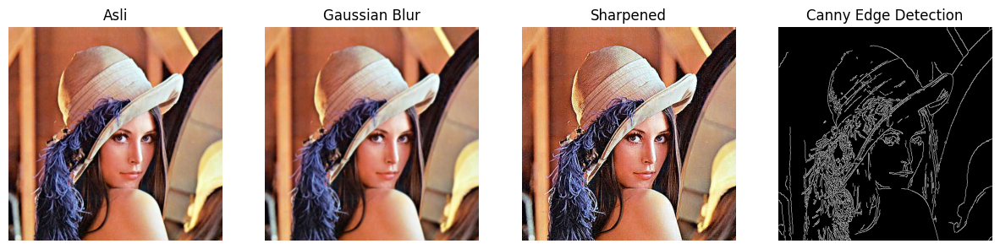

In [125]:
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (im_, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if len(im_.shape) == 2:   # grayscale
            plt.imshow(im_, cmap="gray")
        else:                     # color
            plt.imshow(cv.cvtColor(im_, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/drive/MyDrive/Semester5/PCVK/P6_Arifah_04/lena.jpg.jpeg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7, 7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

Percobaan 2: Pada percobaan 2 berikut ini akan dilakukan filtering modern dari Library OpenCV. Dua filter yang akan digunakan adalah Bilateral Filtering dan Guided Filter. Bilateral filtering adalah sebuah metode penyaringan non-linear yang banyak digunakan untuk menghaluskan citra sekaligus tetap mempertahankan ketajaman tepi. Berbeda dengan Gaussian blur biasa yang hanya memperhitungkan jarak spasial antar piksel, bilateral filter juga mempertimbangkan perbedaan intensitas warna. Dengan cara ini, piksel-piksel yang letaknya dekat dan memiliki warna mirip dengan pusat jendela akan mendapat bobot lebih besar dalam perhitungan, sedangkan piksel dengan perbedaan warna kontras (misalnya di sisi tepi) akan tereduksi pengaruhnya. Akibatnya, citra menjadi lebih halus pada area datar, namun garis batas dan detail penting tetap terjaga. Meskipun menghasilkan kualitas yang baik, bilateral filter tergolong lambat karena perhitungan bobot yang cukup kompleks. Dalam praktiknya, filter ini banyak dipakai untuk keperluan seperti perbaikan kualitas foto, pengurangan noise, maupun sebagai dasar dari efek beauty filter untuk melembutkan tekstur kulit tanpa mengaburkan kontur wajah.

Guided filtering merupakan teknik yang lebih modern dan efisien. Filter ini didasarkan pada asumsi bahwa, dalam sebuah jendela lokal, hasil penyaringan dapat direpresentasikan sebagai fungsi linear dari citra pemandu (guide image). Artinya, setiap piksel keluaran dihitung dengan mempertimbangkan hubungan linier antara nilai piksel di citra masukan dengan nilai piksel pada citra pemandu. Jika citra masukan dan citra pemandu sama, guided filter akan berperan mirip bilateral filter namun dengan perhitungan yang jauh lebih cepat dan hasil yang lebih halus. Keunggulan lainnya, guided filter bisa menggunakan citra yang berbeda sebagai pemandu sehingga mampu mengarahkan proses filtering sesuai kebutuhan. Berkat sifat ini, guided filter sering dipakai dalam berbagai aplikasi lanjutan seperti HDR tone mapping, peningkatan detail, image matting, feathering, serta pemurnian depth map pada sistem stereo vision. Secara umum, guided filter menawarkan keseimbangan antara preservasi tepi yang baik, kualitas visual yang halus, dan efisiensi komputasi, sehingga dianggap sebagai penyempurnaan dari pendekatan bilateral filtering.

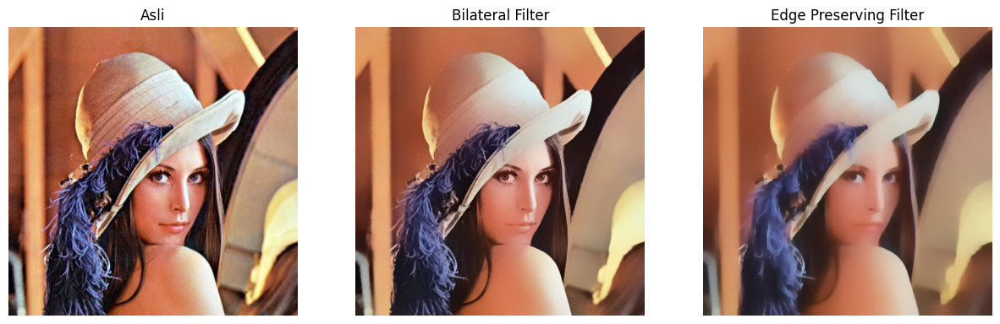

In [126]:
#Filter Modern dari OpenCV
#Bilateral FIlter (edge-preserving
bilateral = cv.bilateralFilter(img, 50,100,100)

#Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

Percobaan 3: Percobaan kali ini akan mencoba melihat proses Filtering pada CNN (bagian Feature Map), lakukan running code beberapa kali dan perhatikan hasil outputnya. Apa yang dapat kamu simpulkan dari hasil keluaran tersebut.

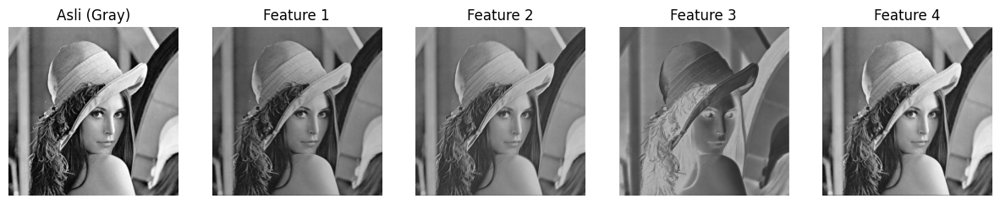

In [127]:
#Filter Feature Map yang digunakan pada CNN, lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)
model = SimpleCNN()

#Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) /255.0

#Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

#Viasulisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

Hasil feature map berubah-ubah setiap kali di-run karena bobot filter di Conv2d diinisialisasi secara acak.

Secara visual:

* Tiap filter nangkep pola yang beda (ada yang kayak deteksi tepi, ada yang gelap/blur).

* Ukuran feature map tetap sama karena pakai padding=1 dan stride=1.

Kesimpulan: Karena model belum di-training, filternya masih random. Filter baru bakal nangkep fitur yang berguna (tepi, tekstur) kalau udah dilatih pakai data banyak.



Percobaan 4: Percobaan kali ini akan melakukan efek Beauty dan Vintage yang biasanya digunakan pada Aplikasi popular saat ini. Filter yang digunakan merupakan kombinasi dari filter tradisional. Perlu diketahui untuk filter aplikasi popular bisa jadi tidak menggunakan metode yang sama. Pada Aplikasi popular bisa jadi menggunakan model GenAI dengan data Training untuk memberikan hasil yang lebih akurat.

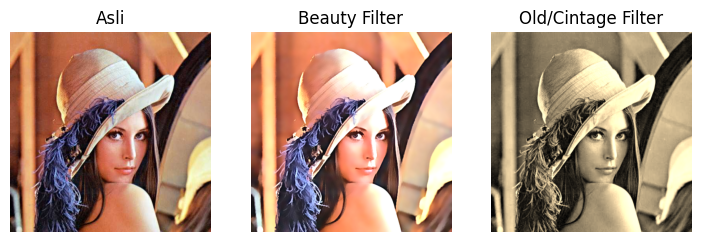

In [128]:
# ======================
# 1. Beauty Filter
# ======================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajaman mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)


# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta  = 15   #brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# =====================
# 2. Old/Vintage Filter
# =====================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                      [0.349, 0.686, 0.168],
                      [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, sepia, vignette, old_img],
                  ["Asli", "Beauty Filter", "Old/Cintage Filter"])

Percobaan 5: Percobaan 5 akan menunjukkan pada anda filter anime / cartoon menggunakan kombinasi filter tradisional.

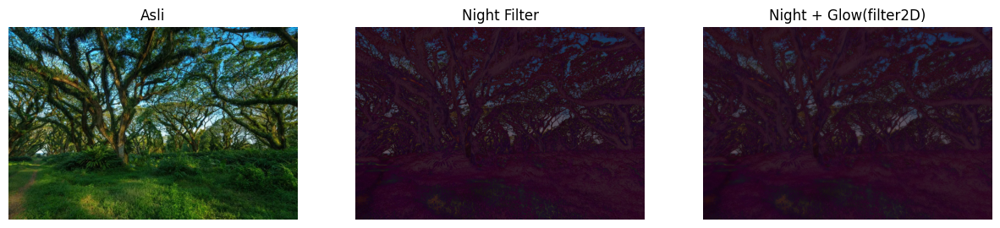

In [129]:
#Night Filter
img = cv.imread("/content/drive/MyDrive/Semester5/PCVK/P6_Arifah_04/djawatan.jpg.jpeg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))    #BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) /225
glow = cv.filter2D(night, -1, kernel)

#Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow(filter2D)"])

Percobaan 7 Percobaan 7 menunjukkan Filter Pagi dan Pagi ditambahkan efek kabut.

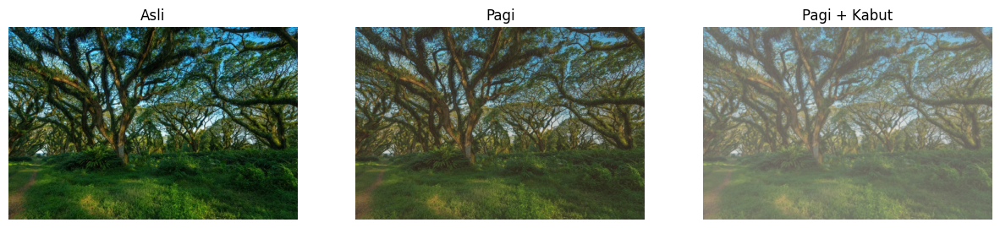

In [130]:
# Filter Suasana pagi dan Kabut
# ==================================
# Step 1: Kurangi kontras & cerahkan
# ==================================
alpha = 0.9   #contrast
beta = 20     #brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# ==================================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# ==================================
warm_tint = np.full_like(soft, (40, 70, 120))    #BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# ==================================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# ==================================
# Kernel blur Gaussian-Like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T    #jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# Tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

#Tugas Praktikum

1. Tugas Analisis: Perbandingan Mean Filter (Blur Biasa) vs. Median Filter pada Noise “Salt and Pepper”

a. Tambahkan noise bintik hitam-putih (Salt and Pepper) ke sebuah citra keabuan (grayscale).  


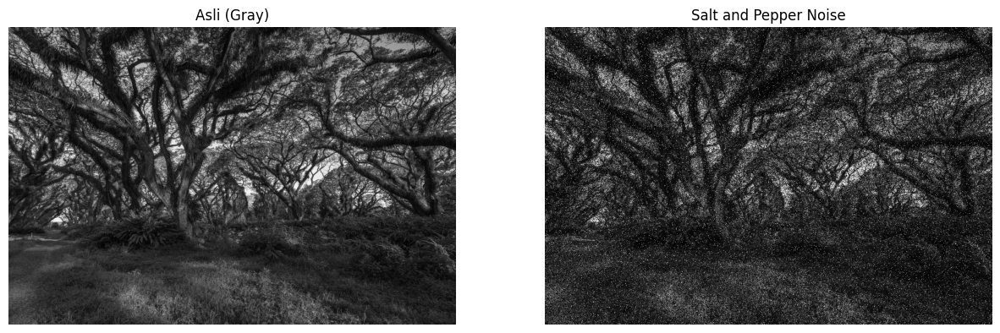

In [131]:
# Tambahkan noise salt and pepper ke citra grayscale
noise = np.random.rand(img_gray.shape[0], img_gray.shape[1])

img_noise = np.copy(img_gray)
img_noise[noise < 0.300] = 0      # pepper (bintik hitam)
img_noise[noise > 0.975] = 255    # salt (bintik putih)

show_side_by_side([img_gray, img_noise],
                  ["Asli (Gray)", "Salt and Pepper Noise"])

b. Terapkan Mean Filter(3 x 3) dan Median Filter (3 x 3).  

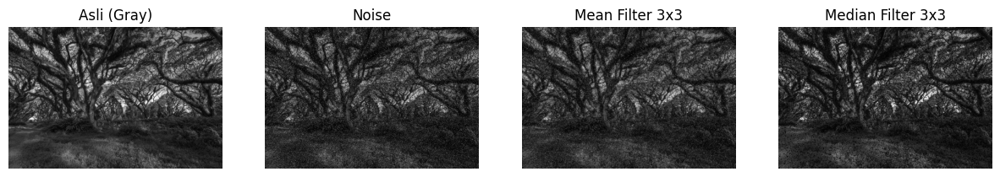

In [132]:
# Mean Filter 3x3
kernel = np.ones((3, 3), np.float32) / 9
mean = cv.filter2D(img_noise, -1, kernel)

# Median Filter 3x3
median = cv.medianBlur(img_noise, 3)

show_side_by_side([img_gray, img_noise, mean, median],
                  ["Asli (Gray)", "Noise", "Mean Filter 3x3", "Median Filter 3x3"])

c. Amati dan analisis secara visual mengapa Median Filter jauh lebih bersih dalam menghapus noise tersebut dibanding Mean Filter.

JAWAB:
*   Mean Filter (Rata-rata): Menjumlahkan semua piksel lalu dibagi. Noise salt and pepper (nilai ekstrem 0 atau 255) ikut dihitung, sehingga nilai rata-ratanya rusak dan menyebar ke piksel tetangga. Akibatnya noise cuma meredup tapi melebar jadi blur.
*   Median Filter (Nilai Tengah): Mengurutkan nilai piksel lalu ambil yang tengah. Nilai ekstrem noise dibuang karena berada di urutan paling ujung, bukan di tengah. Akibatnya noise hilang total tanpa mengubah nilai piksel sekitarnya.

2. Tugas Evaluasi: Pemilihan Ukuran Kernel terbaik untuk Menajamkan Citra (Sharpening)

a. Buat kernel penajaman (Sharpening Kernel) ukuran 3 x 3 dan 5 x 5.

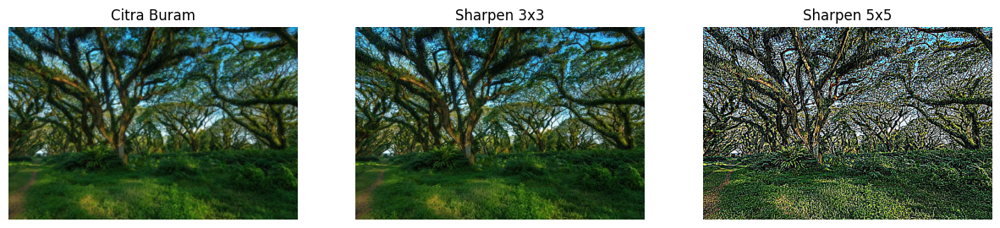

In [133]:
# Sharpening kernel 3x3 (dari modul)
sharpen_3 = np.array([[0, -1, 0],
                        [-1, 5, -1],
                        [0, -1, 0]])

# Sharpening kernel 5x5 (pusat 25, tetangga -1, jumlah elemen = 1)
sharpen_5 = np.array([[-1, -1, -1, -1, -1],
                        [-1, -1, -1, -1, -1],
                        [-1, -1, 25, -1, -1],
                        [-1, -1, -1, -1, -1],
                        [-1, -1, -1, -1, -1]])

hasil_3 = cv.filter2D(img_blur, -1, sharpen_3)
hasil_5 = cv.filter2D(img_blur, -1, sharpen_5)

show_side_by_side([img_blur, hasil_3, hasil_5],
                  ["Citra Buram", "Sharpen 3x3", "Sharpen 5x5"])

b. Terapkan pada citra yang sedikit buram (blurry).  

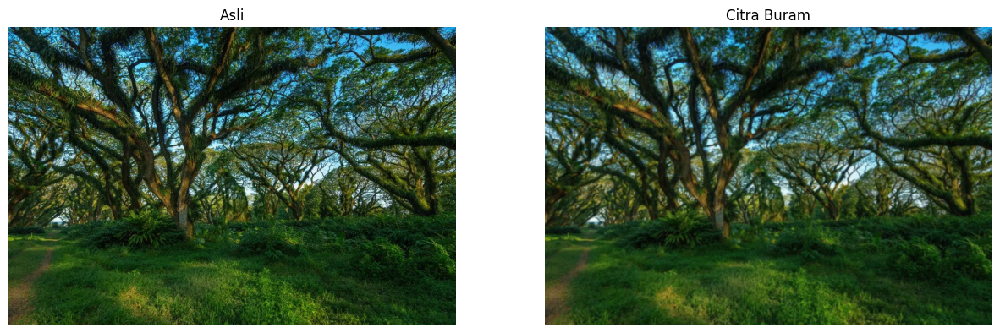

In [134]:
img_blur = cv.GaussianBlur(img, (7, 7), 1)

show_side_by_side([img, img_blur], ["Asli", "Citra Buram"])

c. Evaluasi hasilnya berdasarkan aspek Kejelasan Tepi vs. Kadar Noise/Noise Distortion yang dihasilkan. Tentukan kernel mana yang paling optimal untuk digunakan sehari-hari.

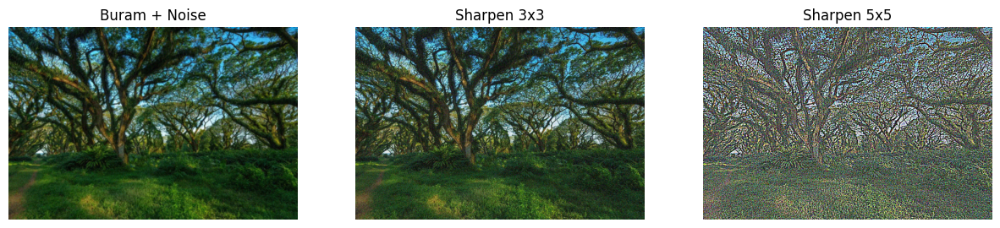

In [135]:
noise = np.random.normal(0, 10, img_blur.shape).astype(np.int16)
img_blur_noise = np.clip(img_blur.astype(np.int16) + noise, 0, 255).astype(np.uint8)

noise_3x3 = cv.filter2D(img_blur_noise, -1, sharpen_3x3)
noise_5x5 = cv.filter2D(img_blur_noise, -1, sharpen_5x5)

show_side_by_side([img_blur_noise, noise_3x3, noise_5x5],
                  ["Buram + Noise", "Sharpen 3x3", "Sharpen 5x5"], figsize=(15, 5))

Jadi kalau dilihat dari hasil eksperimen gambar diatas, hasil analisis saya berdasarkan aspek **Kejelasan Tepi vs Kadar Noise**:

**1. Sharpen 3x3 (Kernel Kecil)**
*   **Kejelasan Tepi:** Lumayan. Tepi ranting dan daun mulai keliatan lebih tegas dibanding gambar "Buram + Noise" yang aslinya.
*   **Kadar Noise:** Noise-nya ikut ketajaman, tapi masih *acceptable*. Noise yang muncul masih halus, belum terlalu mengganggu mata. Tekstur gambar masih keliatan natural.

**2. Sharpen 5x5 (Kernel Besar)**
*   **Kejelasan Tepi:** Tepinya emang jadi sangat tegas (over-sharpened).
*   **Kadar Noise:** Ini yang jadi masalah. Karena kernelnya lebih besar (25 piksel), dia ngelakuin penghitungan yang lebih agresif. Akibatnya, **noise-nya ikut di-sharpen parah**. Muncul banyak bintik-bintik warna aneh (artifak) di area yang harusnya polos, kayak di langit atau rumput. Gambarnya jadi keliatan *over-contrast* dan "kotor" banget. Ini yang sering disebut *noise amplification*.

**Kesimpulan & Rekomendasi (Kernel Paling Optimal):**

Menurut saya, **Sharpen 3x3** adalah yang paling optimal buat dipakai sehari-hari.

Alasannya:
Kita butuh keseimbangan. Sharpen 5x5 sih emang bikin gambar keliatan tajam banget, tapi dia ngorbanin kualitas gambar dengan *noise* yang muncul di mana-mana. Sementara Sharpen 3x3 udah cukup ngangkat detail tepi (edge) tanpa harus nge-*boost* noise yang ada di gambar.

Jadi buat pemakaian umum, saya lebih mending pakai kernel yang kecil (3x3) aja. Kalaupun noise-nya masih ganggu, kita bisa tambahin filter penghalus (denoising) setelahnya. Tapi kalau pakai 5x5, noise-nya udah terlalu parah buat dibersihin tanpa bikin gambar jadi blur lagi.

3. Tugas Kreasi: Filter Kartun Sederhana

a. Buatlah sebuah fungsi kustom bernama kartun(image) yang menggabungkan:  
* Penghalusan warna menggunakan **Bilateral Filter** agar area warna menjadi rata.  
* Deteksi garis tepi menggunakan **Adaptive Thresholding** atau **Canny Edge**.  
* Penggabungan (kombinasi) keduanya menggunakan operasi logika/perkalian piksel.

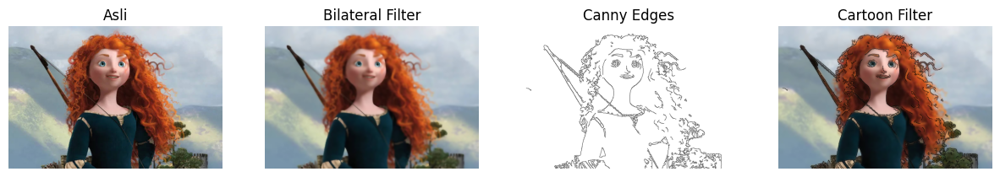

In [136]:
def kartun(image):
    # Step 1: Bilateral
    bilateral = cv.bilateralFilter(image, 9, 200, 200)

    # Step 2: Canny Edge
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    edges = cv.Canny(gray, 100, 200)

    # Step 3: Invert edges untuk menyamakan channel
    edges_inv = cv.bitwise_not(edges)

    # Step 4: Penggabungan Bilateral dan Canny
    cartoon = cv.bitwise_and(bilateral, bilateral, mask=edges_inv)

    return bilateral, edges_inv, cartoon

image = cv.imread("/content/drive/MyDrive/Semester5/PCVK/P6_Arifah_04/kartun.jpeg")
bilateral, edges_inv, cartoon = kartun(image)
show_side_by_side([image, bilateral, edges_inv, cartoon],
                  ["Asli", "Bilateral Filter", "Canny Edges", "Cartoon Filter"])

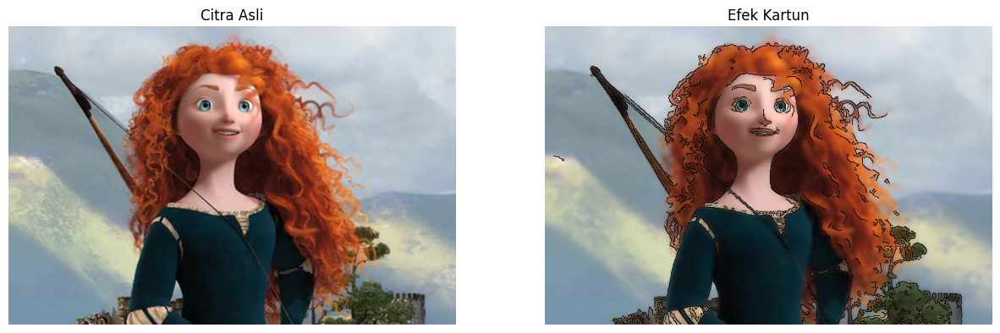

In [137]:
# Load citra
image = cv.imread("/content/drive/MyDrive/Semester5/PCVK/P6_Arifah_04/kartun.jpeg")

bilateral, edges_inv, cartoon = kartun(image)
show_side_by_side([image, cartoon],
                  ["Citra Asli", "Efek Kartun"])